# 🐟 Fish Weight Prediction - Polynomial Regression

**🇹🇷 Türkçe:**
Bu projede balıkların fiziksel özelliklerini (Uzunluk, Yükseklik, Genişlik) kullanarak **Ağırlık (Weight)** tahminlemesi yapıyoruz. Veri seti içerisindeki değişkenlerin doğrusal olmayan eğrisel ilişkilerini yakalayabilmek adına modelimizi **Polinom Regresyon (Polynomial Regression)** mimarisiyle kuracağız.

**🇬🇧 English:**
In this project, we predict the **Weight** of fish using their physical measurements (Length, Height, Width). To effectively capture the non-linear, curved relationships between these features, we will build our model using **Polynomial Regression** architecture.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../../Data/Fish.csv")

In [3]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 📊 Keşifçi Veri Analizi / Exploratory Data Analysis (EDA)

**🇹🇷 Türkçe:**
Değişkenler arasındaki ilişkiyi görselleştiriyoruz. Özellikle balığın uzunluğu (Length) ve yüksekliği (Height) arttıkça ağırlığının (Weight) düz bir çizgiden çok **eğrisel bir şekilde (parabolik)** arttığını görebiliriz. Bu durum polinom regresyon kullanmamızın ana sebebidir.

**🇬🇧 English:**
We visualize the relationships between variables. As the length and height of the fish increase, the weight increases in a **curved (parabolic) manner** rather than a straight line. This observation is the main reason we choose polynomial regression.

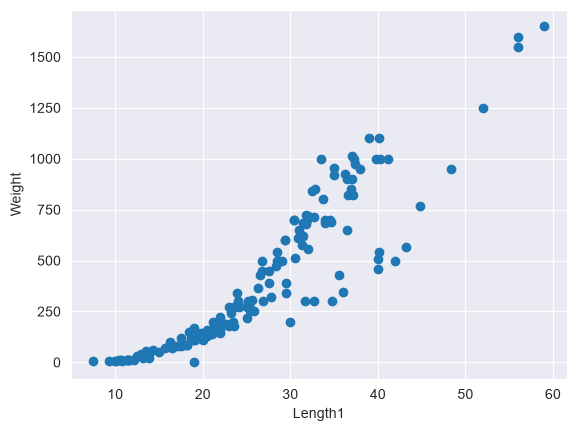

In [4]:
plt.scatter(df["Length1"], df["Weight"])
plt.xlabel("Length1")
plt.ylabel("Weight")
plt.show()


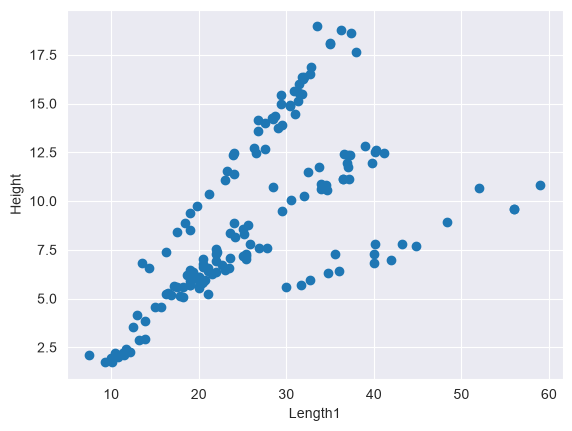

In [5]:
plt.scatter(df["Length1"], df["Height"])
plt.xlabel("Length1")
plt.ylabel("Height")
plt.show()


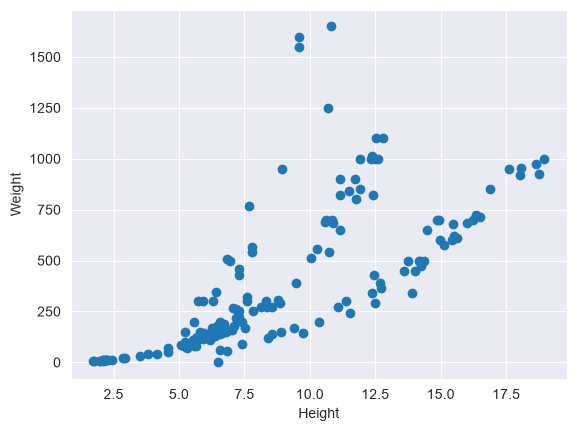

In [6]:
plt.scatter(df["Height"], df["Weight"])
plt.xlabel("Height")
plt.ylabel("Weight")
plt.show()


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X = df[["Length1", "Length2", "Length3", "Height","Width"]]
y = df["Weight"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

In [10]:
X_train

,Length1,Length2,Length3,Height,Width
58,28.5,31.0,34.0,10.7440,6.5620
57,25.6,28.0,30.8,8.7780,4.6816
137,42.0,45.0,48.0,6.9600,4.8960
55,23.6,26.0,28.7,8.3804,4.2476
47,21.1,22.5,25.0,6.4000,3.8000
...,...,...,...,...,...
85,19.3,21.3,22.8,6.3840,3.5340
128,30.0,32.3,34.8,5.5680,3.3756
119,36.9,40.0,42.3,11.9286,7.1064
133,36.0,38.5,41.0,6.3960,3.9770


## ⚙️ Veri Ön İşleme ve Ölçeklendirme / Data Preprocessing & Scaling

**🇹🇷 Türkçe:**
Modelde Data Leakage (Veri Sızıntısı) olmasını önlemek için ölçeklendirme (scaling) işlemlerini veriyi **Train** ve **Test** olarak böldükten sonra yapıyoruz. `StandardScaler` ile değerleri aynı ölçeğe (Z-Skor) standartlaştırıyoruz.

**🇬🇧 English:**
To prevent Data Leakage, we apply scaling only after splitting the data into **Train** and **Test** sets. We use `StandardScaler` to standardize the values into a common scale (Z-Score).

In [11]:
from sklearn.preprocessing import StandardScaler

In [12]:
scaler = StandardScaler()

In [13]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 🧮 Polinom Özellik Mühendisliği / Polynomial Feature Engineering

**🇹🇷 Türkçe:**
Sıradan doğrusal regresyon bu verideki eğrisel yapıyı tam öğrenemez. Bu yüzden `PolynomialFeatures(degree=2)` kullanarak orijinal değişkenlerin karesel değerlerini ve birbiriyle çarpımlarını (etkileşimlerini) içeren yeni sütunlar üreterek verimizi 2. dereceden polinoma çeviriyoruz.

**🇬🇧 English:**
Simple linear regression cannot fully capture the curved structure of this data. Therefore, we use `PolynomialFeatures(degree=2)` to transform our data into a 2nd-degree polynomial, creating new columns that include squared values and interaction terms of the original variables.

In [14]:
from sklearn.preprocessing import PolynomialFeatures

In [15]:
poly = PolynomialFeatures(degree = 2)

In [16]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.fit_transform(X_test)

## 📈 Model Eğitimi ve Değerlendirme / Model Training & Evaluation

**🇹🇷 Türkçe:**
Dönüştürülmüş polinom özelliklerimizle Linear Regression modelimizi eğitiyoruz. Modelin başarısını **$R^2$ Skoru** ile ölçüyoruz. Sonuç **%98.1** çıkarak modelin bağımsız değişkenler ile ağırlığı neredeyse kusursuz açıkladığını gösteriyor!

**🇬🇧 English:**
We train our Linear Regression model using the transformed polynomial features. We measure the success of the model using the **$R^2$ Score**. The result is **98.1%**, indicating that our model explains the variance in weight almost perfectly!

In [17]:
from sklearn.linear_model import LinearRegression

In [18]:
regression = LinearRegression()
regression.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0. , 33.14, 176.5 ,...,-110.82, 197.35, -32.95]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,325.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](21,)","[47.84,27.22,20.09,..., 0.01, 0. , 0. ]"


In [19]:
y_pred = regression.predict(X_test_poly)

In [20]:
from sklearn.metrics import mean_squared_error, r2_score

In [21]:
r2 = r2_score(y_test, y_pred)

In [22]:
print(r2)

0.9815870176224161
